# Medicaid Provider Spending — EDA (Updated Dataset)

Data sourced from the [HHS Open Data Platform](https://opendata.hhs.gov/datasets/medicaid-provider-spending/).

## Dataset Overview

This dataset contains provider-level Medicaid spending aggregated from outpatient and professional claim lines with populated HCPCS codes. It covers **January 2018 through December 2024** across all 50 states and territories, and includes fee-for-service claims, managed care encounters, and CHIP — a broader scope than the previous version.

Each row represents a unique combination of billing provider × servicing provider × HCPCS procedure code × month. Rows with fewer than 12 claim lines or fewer than 12 unique beneficiaries are suppressed for privacy.

## Columns

| Column | Type | Description |
|---|---|---|
| `BILLING_PROVIDER_NPI_NUM` | varchar | NPI of the provider who submitted the claim (nullable) |
| `SERVICING_PROVIDER_NPI_NUM` | varchar | NPI of the provider who delivered the service (nullable) |
| `HCPCS_CODE` | varchar | Healthcare procedure code |
| `CLAIM_FROM_MONTH` | varchar | Service month in `YYYY-MM` format |
| `TOTAL_PATIENTS` | int64 | Unique beneficiaries served (new in v2) |
| `TOTAL_CLAIM_LINES` | int64 | Number of claim lines (not top-level claims) |
| `TOTAL_PAID` | double | Total Medicaid dollars paid (summed at the line level) |

## Differences from Previous Dataset (v1)

| | v1 | v2 (this dataset) |
|---|---|---|
| **Time period** | Through ~2022 | Jan 2018 – Dec 2024 |
| **Coverage** | Fee-for-service only | Fee-for-service + managed care + CHIP |
| **Beneficiary count** | Not available | `TOTAL_PATIENTS` added |
| **Claim count field** | `TOTAL_CLAIMS` (claim-level) | `TOTAL_CLAIM_LINES` (line-level — will be higher) |
| **Null NPIs** | None | Both NPI columns are nullable |

## Known Data Quality Issues

- **NPI `5200000300`**: A servicing provider not found in the NPI registry whose rows contain trillion-dollar `TOTAL_PAID` values, particularly in Jan, Feb, and Jun 2018. Smaller but still anomalous values persist through 2019. Almost certainly a data submission error.
- **Null billing NPIs**: Rows missing a billing NPI represent ~3% of rows but ~93% of total dollars — this is not random missingness, it reflects upstream provider identification failures.
- **Early 2018**: Heavily skewed by the above. HHS's own example visualization starts from October 2018 and filters to rows where both NPIs are present.
- **Late 2024**: Spending drops sharply — this data is preliminary and subject to revision as states finalize T-MSIS submissions.

# Medicaid Provider Spending — EDA (Updated Dataset)

Data sourced from the [HHS Open Data Platform](https://opendata.hhs.gov/datasets/medicaid-provider-spending/).
Previously analyzed data was sourced from an earlier version of this dataset, so let's start with an updated overview to understand the differences and any new data quality issues before diving into analysis. Data format has stayed the same, with a few column changes. Overall row count has incresed from 227 million to 238 million. 

## Dataset Overview

This dataset contains provider-level Medicaid spending aggregated from outpatient and professional claim lines with populated HCPCS codes. It covers **January 2018 through December 2024** across all 50 states and territories, and includes fee-for-service claims, managed care encounters, and CHIP.

Each row represents a unique combination of billing provider × servicing provider × HCPCS procedure code × month. Rows with fewer than 12 claim lines or fewer than 12 unique beneficiaries are suppressed for privacy.

## Columns

| Column | Type | Description |
|---|---|---|
| `BILLING_PROVIDER_NPI_NUM` | varchar | NPI of the provider who submitted the claim (nullable) |
| `SERVICING_PROVIDER_NPI_NUM` | varchar | NPI of the provider who delivered the service (nullable) |
| `HCPCS_CODE` | varchar | Healthcare procedure code |
| `CLAIM_FROM_MONTH` | varchar | Service month in `YYYY-MM` format |
| `TOTAL_PATIENTS` | int64 | Unique beneficiaries served |
| `TOTAL_CLAIM_LINES` | int64 | Number of claim lines  |
| `TOTAL_PAID` | double | Total Medicaid dollars paid (summed at the line level) |


## Known Data Quality Issues

- **NPI `5200000300`**: A servicing provider not found in the NPI registry whose rows contain trillion-dollar `TOTAL_PAID` values, particularly in Jan, Feb, and Jun 2018. Smaller but still anomalous values persist through 2019. Almost certainly a data submission error.
- **Null billing NPIs**: Rows missing a billing NPI represent ~3% of rows but ~93% of total dollars — this is not random missingness, it reflects upstream provider identification failures.
- **Early 2018**: Heavily skewed by the above. HHS's own example visualization starts from October 2018 and filters to rows where both NPIs are present.
- **Late 2024**: Spending drops sharply — this data is preliminary and subject to revision as states finalize T-MSIS submissions.



In [23]:
import duckdb
import polars as pl
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

duckdb_path = '/Users/adilkassim/Downloads/medicaid-provider-spending.duckdb'
con = duckdb.connect(f"{duckdb_path}")



In [24]:
## First 20 Rows
con.sql("select * from dataset limit 20")


┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────┬───────────────────┬──────────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_PATIENTS │ TOTAL_CLAIM_LINES │    TOTAL_PAID    │
│         varchar          │          varchar           │  varchar   │     varchar      │     int64      │       int64       │      double      │
├──────────────────────────┼────────────────────────────┼────────────┼──────────────────┼────────────────┼───────────────────┼──────────────────┤
│ NULL                     │ 5200000300                 │ 20         │ 2018-06          │            915 │              8403 │ 7469333333258.64 │
│ NULL                     │ 5200000300                 │ 20         │ 2018-01          │            874 │              7368 │ 6549333333267.84 │
│ NULL                     │ 5200000300                 │ 20         │ 2018-02          │            878 │              6962

Surprising to see rows missing a billing provider NPI and even more surprising to see rows missing both billing and servicing provider NPIs as the older dataset had no missing NPIs.

We will investigate this further in our analysis


## Let's verify data types and nullability assumptions before proceeding with analysis.

### NPI's should be 10-digit numeric strings, and HCPCS codes should be 5-digit alphanumeric strings. Let's check for any deviations from these formats, as well as the presence of nulls in the NPI fields.

In [25]:
con.sql("""
    SELECT 
        LENGTH(HCPCS_CODE) AS code_length,
        COUNT(*) AS count
    FROM claims_2018
    GROUP BY code_length
    ORDER BY code_length
""")


┌─────────────┬──────────┐
│ code_length │  count   │
│    int64    │  int64   │
├─────────────┼──────────┤
│           2 │        2 │
│           3 │       92 │
│           4 │    53117 │
│           5 │ 27218814 │
│           6 │       14 │
│           7 │      475 │
│           8 │        2 │
└─────────────┴──────────┘

In [26]:
con.sql("""
    SELECT 
        COUNT(*) as count,
        LENGTH(BILLING_PROVIDER_NPI_NUM) as length,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_null
    FROM dataset 
    GROUP BY length
""")


┌───────────┬────────┬──────────┐
│   count   │ length │ pct_null │
│   int64   │ int64  │  double  │
├───────────┼────────┼──────────┤
│   7806309 │   NULL │     3.28 │
│ 230209420 │     10 │    96.72 │
└───────────┴────────┴──────────┘

In [27]:

con.sql("""
    SELECT 
        COUNT(*) as count,
        LENGTH(SERVICING_PROVIDER_NPI_NUM) as length,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_null
    FROM dataset 
    GROUP BY length
""")


┌───────────┬────────┬──────────┐
│   count   │ length │ pct_null │
│   int64   │ int64  │  double  │
├───────────┼────────┼──────────┤
│   9107839 │   NULL │     3.83 │
│ 228907890 │     10 │    96.17 │
└───────────┴────────┴──────────┘

#### Both servicing and billing provider NPI's correctly have 10 digits, althogh they have some null values. 


In [28]:

con.sql("""
    SELECT 
        COUNT(*) as count,
        LENGTH(HCPCS_CODE) as length,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_null
    FROM dataset 
    GROUP BY length
    ORDER BY count
""")


┌───────────┬────────┬──────────┐
│   count   │ length │ pct_null │
│   int64   │ int64  │  double  │
├───────────┼────────┼──────────┤
│        14 │      1 │      0.0 │
│        17 │      8 │      0.0 │
│       515 │      3 │      0.0 │
│      3007 │      6 │      0.0 │
│      3118 │      7 │      0.0 │
│      5803 │      2 │      0.0 │
│    364925 │      4 │     0.15 │
│ 237638330 │      5 │    99.84 │
└───────────┴────────┴──────────┘

May potential drop rows with null NPI's and incorrect HCPCS code length. Let's continue investigating the data though for now. 

In [29]:
con.sql("""
SELECT
    (BILLING_PROVIDER_NPI_NUM IS NULL) AS billing_null,
    (SERVICING_PROVIDER_NPI_NUM IS NULL) AS servicing_null,
    COUNT(*) as num_of_rows,
    SUM(TOTAL_PAID) as total_paid
FROM dataset
GROUP BY all
"""
)

┌──────────────┬────────────────┬─────────────┬────────────────────┐
│ billing_null │ servicing_null │ num_of_rows │     total_paid     │
│   boolean    │    boolean     │    int64    │       double       │
├──────────────┼────────────────┼─────────────┼────────────────────┤
│ true         │ false          │     7532557 │ 20323545953163.785 │
│ false        │ false          │   221375333 │  1003056531502.439 │
│ false        │ true           │     8834087 │ 101591461189.00836 │
│ true         │ true           │      273752 │  371205742714.1438 │
└──────────────┴────────────────┴─────────────┴────────────────────┘

In [30]:
df = con.sql("""
WITH agg AS (
    SELECT
        SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
        (BILLING_PROVIDER_NPI_NUM IS NULL) AS billing_null,
        (SERVICING_PROVIDER_NPI_NUM IS NULL) AS servicing_null,
        COUNT(*) AS num_of_rows,
        SUM(TOTAL_PAID) AS total_paid
    FROM dataset
    GROUP BY ALL
)
SELECT
    year,
    billing_null,
    servicing_null,
    num_of_rows,
    ROUND(num_of_rows * 100.0 / SUM(num_of_rows) OVER (PARTITION BY year), 2) AS pct,
    total_paid,
    ROUND(total_paid * 100.0 / SUM(total_paid) OVER (PARTITION BY year), 2) AS paid_pct
FROM agg
ORDER BY year
""").to_df()


In [31]:

df["status"] = (
    df[["billing_null", "servicing_null"]]
    .apply(lambda r: (
        "Both Missing"       if r.billing_null and r.servicing_null else
        "Billing Missing"    if r.billing_null else
        "Servicing Missing"  if r.servicing_null else
        "Both Present"
    ), axis=1)
)

pivot = (
    df[["year", "status", "pct", "paid_pct"]]
    .pivot(index="year", columns="status", values=["pct", "paid_pct"])
    .round(2)
)

pivot.columns = [f"{stat} | {col}" for stat, col in pivot.columns]
pivot


,pct | Billing Missing,pct | Both Missing,pct | Both Present,pct | Servicing Missing,paid_pct | Billing Missing,paid_pct | Both Missing,paid_pct | Both Present,paid_pct | Servicing Missing
year,,,,,,,,
2018,4.51,0.14,90.94,4.41,99.27,0.19,0.50,0.04
2019,4.22,0.13,91.42,4.24,24.96,17.51,53.20,4.34
2020,3.08,0.13,92.04,4.74,3.70,23.16,66.89,6.25
2021,2.90,0.11,92.72,4.27,2.70,23.29,66.47,7.53
2022,2.71,0.10,93.95,3.24,2.51,23.48,66.75,7.26
2023,2.68,0.10,94.29,2.92,2.49,24.81,65.64,7.05
2024,2.52,0.11,94.75,2.63,2.44,27.67,63.09,6.81


The majority of rows (93.01%) have both NPIs present. The troubling aspect is that rows missing only a billing provider NPI account for 93.23% of total payments — roughly $20 trillion. This does not make sense, as total annual Medicaid spending is well under $1 trillion.


Let's plot the data to see how it looks — visualizing it may reveal anomalies more clearly.


<Axes: xlabel='year'>

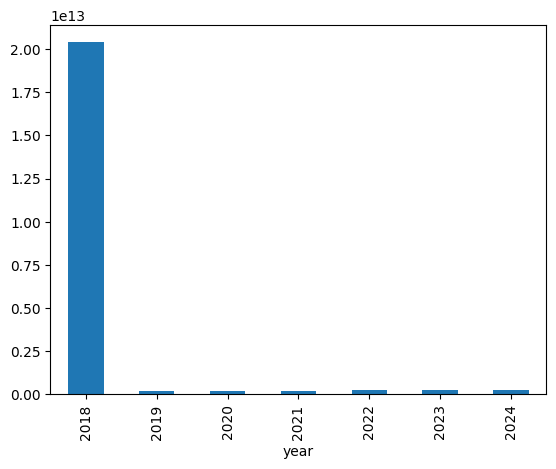

In [32]:
per_year = con.sql("""
SELECT
    SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
    SUM(TOTAL_PAID) AS TOTAL_PAID
FROM dataset
GROUP BY year
ORDER BY year
""").to_df()

per_year.plot.bar(x="year", y="TOTAL_PAID", legend=False)


In [33]:
for _, row in per_year.iterrows():
    print(f"{row['year']}: {row['TOTAL_PAID']}")
    


2018: 20383877394630.953
2019: 222929227068.2743
2020: 182725957403.50793
2021: 220840385816.04437
2022: 244655272048.12918
2023: 276433297242.40875
2024: 267938154373.7001


Clearly something is wrong in 2018 — over $20 trillion appears to have been distributed that year alone.


Let's examine by month in 2018 to see if we can identify when the issue starts.


In [34]:
per_month = con.sql("""
SELECT
    sum(total_paid) as TOTAL_PAID, 
    CLAIM_FROM_MONTH
FROM
    dataset
WHERE SUBSTR(CLAIM_FROM_MONTH, 1, 4) = '2018'
GROUP BY CLAIM_FROM_MONTH
order by  CLAIM_FROM_MONTH
"""
).to_df()

In [35]:
per_month

,TOTAL_PAID,CLAIM_FROM_MONTH
0,6.562095e+12,2018-01
1,6.200209e+12,2018-02
2,1.271733e+10,2018-03
3,1.432379e+10,2018-04
4,1.488778e+10,2018-05
5,7.481644e+12,2018-06
6,1.612801e+10,2018-07
7,2.134688e+10,2018-08
8,1.767347e+10,2018-09
9,1.651839e+10,2018-10


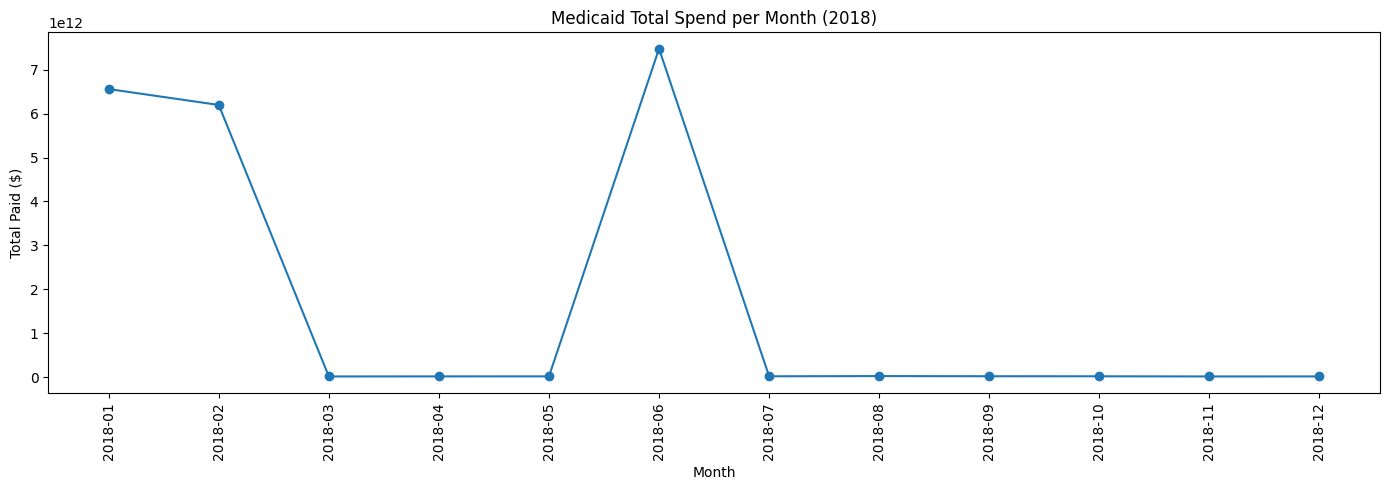

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(per_month["CLAIM_FROM_MONTH"], per_month["TOTAL_PAID"], marker="o", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Total Paid ($)")
ax.set_title("Medicaid Total Spend per Month (2018)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

Clearly something is wrong with the data, specifically in 2018.
The data providers appear to have been aware of this issue — in their example visualization, they only plotted data starting from October 2018, which is when the figures start to look more reasonable. They also filter to rows where both billing and servicing provider NPIs are present.
Let's recreate their visualization.


In [37]:
per_month_after_sep = con.sql("""
SELECT
    sum(total_paid) as TOTAL_PAID, 
    CLAIM_FROM_MONTH
FROM
    dataset
WHERE CLAIM_FROM_MONTH > '2018-09'
AND BILLING_PROVIDER_NPI_NUM is NOT NULL
AND SERVICING_PROVIDER_NPI_NUM IS NOT NULL 
GROUP BY CLAIM_FROM_MONTH
order by  CLAIM_FROM_MONTH
"""
).to_df()

In [38]:
avg_per_month = per_month_after_sep['TOTAL_PAID'].mean()

In [39]:
per_month_after_sep

,TOTAL_PAID,CLAIM_FROM_MONTH
0,9.246470e+09,2018-10
1,8.457151e+09,2018-11
2,8.267035e+09,2018-12
3,9.821253e+09,2019-01
4,9.025005e+09,2019-02
...,...,...
70,1.501142e+10,2024-08
71,1.432105e+10,2024-09
72,1.491811e+10,2024-10
73,1.161741e+10,2024-11


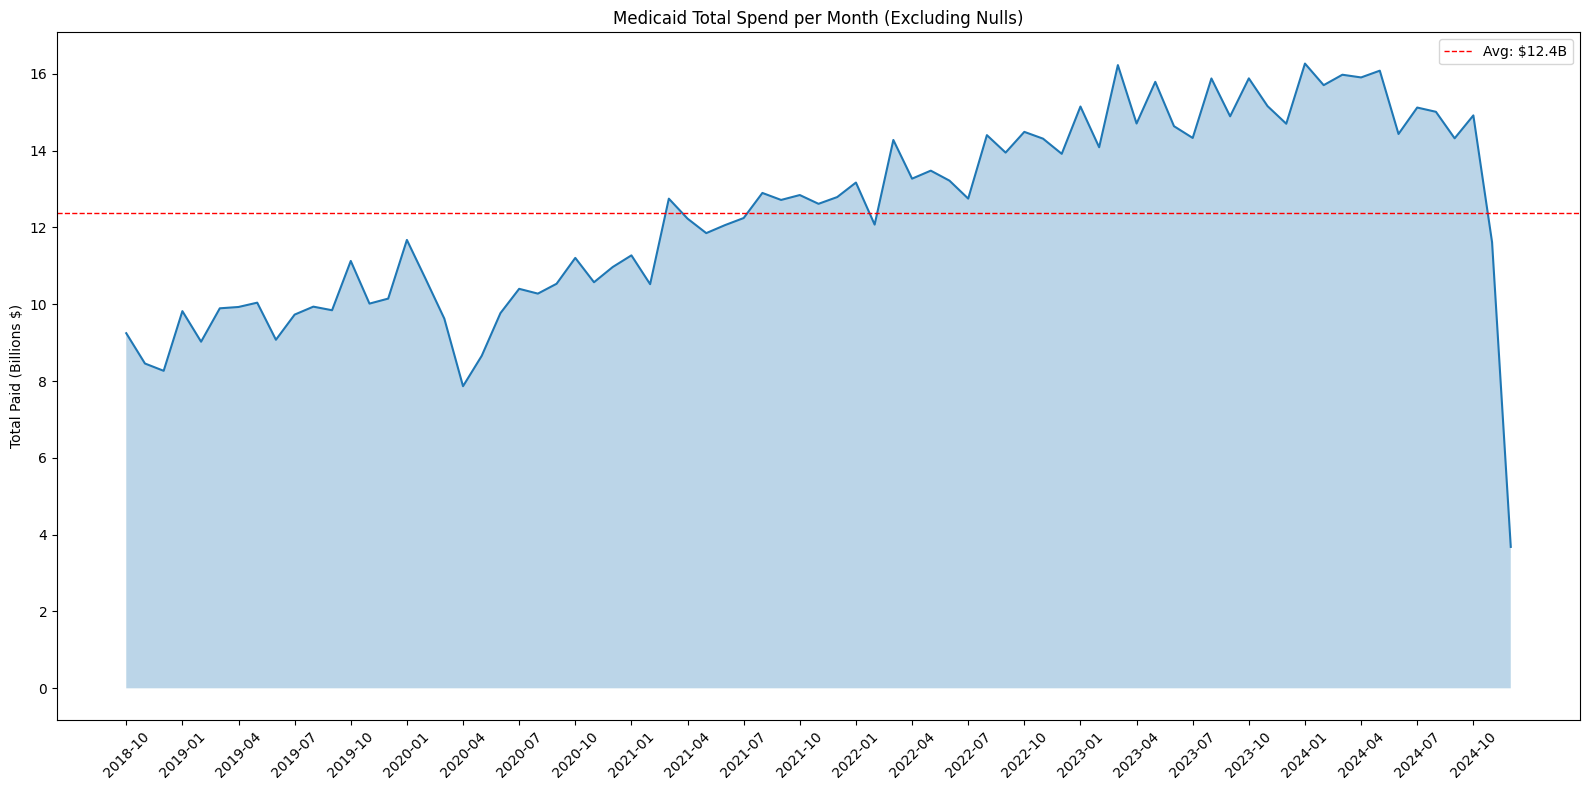

In [40]:
per_month_after_sep = per_month_after_sep.sort_values("CLAIM_FROM_MONTH").reset_index(drop=True)
# change step if you want to see less ticks. rather than have it show for each show every other month, step = 2
step = 3
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(per_month_after_sep["CLAIM_FROM_MONTH"], per_month_after_sep["TOTAL_PAID"] / 1e9)
ax.fill_between(per_month_after_sep["CLAIM_FROM_MONTH"], per_month_after_sep["TOTAL_PAID"] / 1e9, alpha=0.3)
avg = per_month_after_sep["TOTAL_PAID"].mean() / 1e9
ax.axhline(avg, color="red", linestyle="--", linewidth=1, label=f"Avg: ${avg:.1f}B")
ax.legend()
ax.set_xticks(range(0, len(per_month_after_sep), step))
ax.set_xticklabels(per_month_after_sep["CLAIM_FROM_MONTH"][::step], rotation=45)
ax.set_ylabel("Total Paid (Billions $)")
ax.set_title("Medicaid Total Spend per Month (Excluding Nulls)")


plt.tight_layout()
plt.show()


Nearly identical to the example visualization provided by the data providers. The only difference is they chose to end the x-axis at September 2024, while I extended it through end of 2024 — and we can see a sharp decline in the data toward the end of 2024. This could be a data quality issue they chose not to highlight, or it may simply be that the data is incomplete for late 2024.
Let's visualize the data with all rows, including those with missing NPIs, to see how it compares.


In [41]:
all_rows = con.sql("""
SELECT
    sum(total_paid) as TOTAL_PAID, 
    CLAIM_FROM_MONTH
FROM
    dataset
WHERE CLAIM_FROM_MONTH > '2018-09'
GROUP BY CLAIM_FROM_MONTH
order by  CLAIM_FROM_MONTH
"""
).to_df()

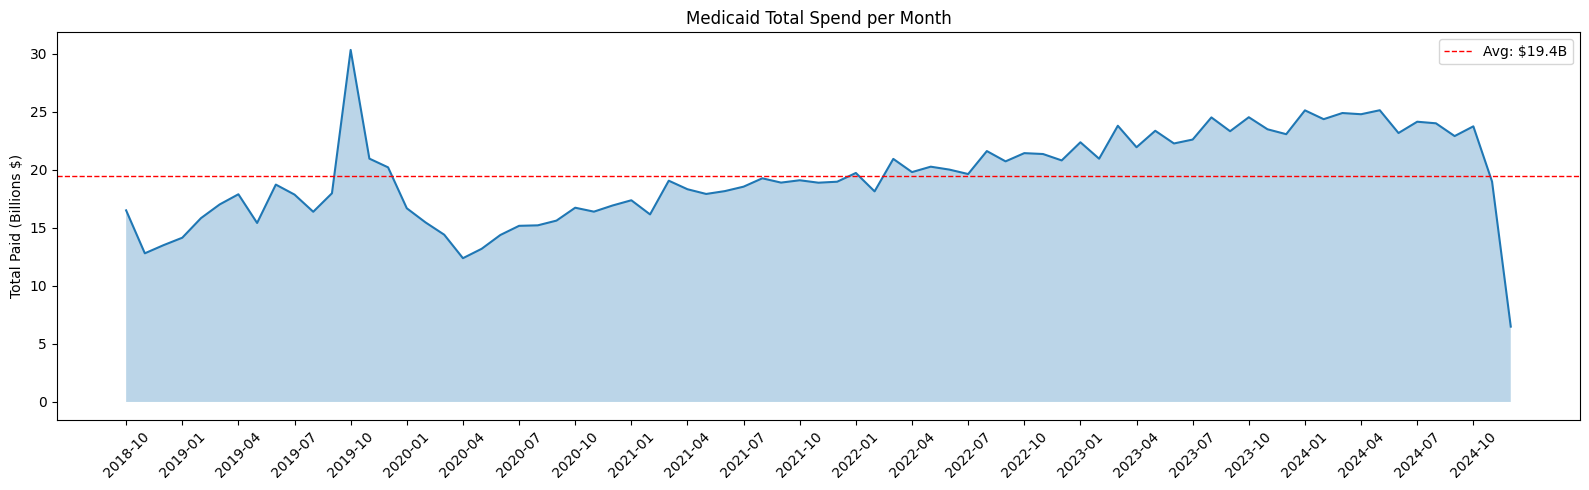

In [42]:
all_rows = all_rows.sort_values("CLAIM_FROM_MONTH").reset_index(drop=True)

avg = all_rows["TOTAL_PAID"].mean() / 1e9
step = 3
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(all_rows["CLAIM_FROM_MONTH"], all_rows["TOTAL_PAID"] / 1e9)
ax.fill_between(all_rows["CLAIM_FROM_MONTH"], all_rows["TOTAL_PAID"] / 1e9, alpha=0.3)
ax.axhline(avg, color="red", linestyle="--", linewidth=1, label=f"Avg: ${avg:.1f}B")
ax.set_xticks(range(0, len(all_rows), step))
ax.set_xticklabels(all_rows["CLAIM_FROM_MONTH"][::step], rotation=45)
ax.set_ylabel("Total Paid (Billions $)")
ax.set_title("Medicaid Total Spend per Month")
ax.legend()
plt.tight_layout()
plt.show()

The graphs look significantly different when rows with NULL billing or servicing provider NPIs are included.
Average monthly spend is noticeably higher when those rows are included, suggesting the missing NPIs are not random — they appear to be associated with disproportionately large payments. This could be due to data entry errors, or it may be that certain provider types or services are more expensive and are more likely to have missing identifiers.


In [43]:
con.sql("""
SELECT
    (BILLING_PROVIDER_NPI_NUM IS NULL) AS billing_null,
    (SERVICING_PROVIDER_NPI_NUM IS NULL) AS servicing_null,
    COUNT(*) as cnt,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as cnt_pct,
    SUM(TOTAL_PAID) as total_paid,
    ROUND(SUM(TOTAL_PAID) * 100.0 / SUM(SUM(TOTAL_PAID)) OVER (), 2) as paid_pct,
    max(TOTAL_PAID), MIN(TOTAL_PAID), AVG(TOTAL_PAID), MEDIAN(TOTAL_PAID)
FROM dataset
GROUP BY 1, 2
ORDER BY cnt DESC
""")

┌──────────────┬────────────────┬───────────┬─────────┬────────────────────┬──────────┬──────────────────┬─────────────────┬────────────────────┬────────────────────┐
│ billing_null │ servicing_null │    cnt    │ cnt_pct │     total_paid     │ paid_pct │ max(TOTAL_PAID)  │ min(TOTAL_PAID) │  avg(TOTAL_PAID)   │ median(TOTAL_PAID) │
│   boolean    │    boolean     │   int64   │ double  │       double       │  double  │      double      │     double      │       double       │       double       │
├──────────────┼────────────────┼───────────┼─────────┼────────────────────┼──────────┼──────────────────┼─────────────────┼────────────────────┼────────────────────┤
│ false        │ false          │ 221375333 │   93.01 │ 1003056531502.9226 │      4.6 │     118999818.09 │      -113643.78 │  4531.022123873768 │             621.14 │
│ false        │ true           │   8834087 │    3.71 │ 101591461189.01656 │     0.47 │      27095930.55 │      -183021.84 │ 11499.938951135138 │             517.25 

The median total paid when both NPIs are missing ($963.62) is roughly 55% higher than when both are present ($621.14).

Notably, the most frequent HCPCS codes in the both-null group are 99213, 99214, 99283, 99284, and 99285 — the same high-volume office visit and ED codes that top the list when both NPIs are present. This rules out intentional anonymisation and strongly suggests a data submission failure where provider identifiers were simply dropped on otherwise normal claims.

For this reason, we will work with the older dataset going forward, as it is complete and does not have this issue.


## HCPS Codes


In [44]:
con.sql("""
SELECT
    HCPCS_CODE, 
    Count(HCPCS_CODE)
FROM
    dataset

WHERE BILLING_PROVIDER_NPI_NUM is NOT NULL
AND SERVICING_PROVIDER_NPI_NUM IS NOT NULL 
GROUP BY HCPCS_CODE
ORDER BY COUNT(HCPCS_CODE) DESC
"""
)

┌────────────┬───────────────────┐
│ HCPCS_CODE │ count(HCPCS_CODE) │
│  varchar   │       int64       │
├────────────┼───────────────────┤
│ 99213      │          13642976 │
│ 99214      │          11852216 │
│ 99284      │           4059022 │
│ 99283      │           3339268 │
│ 99285      │           2935154 │
│ 36415      │           2713536 │
│ T1015      │           2373185 │
│ 85025      │           2236155 │
│ D0120      │           2234387 │
│ 90837      │           1872580 │
│  ·         │                 · │
│  ·         │                 · │
│  ·         │                 · │
│ W51        │                 1 │
│ X4106      │                 1 │
│ Z0141      │                 1 │
│ G8434      │                 1 │
│ 93563      │                 1 │
│ G9176      │                 1 │
│ D0482      │                 1 │
│ 99101      │                 1 │
│ 92601      │                 1 │
│ SMGS0      │                 1 │
└────────────┴───────────────────┘
  ? rows            

# Let's Investigate 2018


In [45]:
con.sql("""
    CREATE OR REPLACE VIEW claims_2018 AS
    SELECT * 
    FROM dataset
    WHERE SUBSTR(CLAIM_FROM_MONTH, 1, 4) = '2018'     
""")

In [46]:
con.sql("""
            
        
""")

In [47]:
con.sql("""
    SELECT *
    FROM claims_2018
    ORDER BY TOTAL_PAID DESC
    LIMIT 10
  
            
""")

┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────┬───────────────────┬──────────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_PATIENTS │ TOTAL_CLAIM_LINES │    TOTAL_PAID    │
│         varchar          │          varchar           │  varchar   │     varchar      │     int64      │       int64       │      double      │
├──────────────────────────┼────────────────────────────┼────────────┼──────────────────┼────────────────┼───────────────────┼──────────────────┤
│ NULL                     │ 5200000300                 │ 20         │ 2018-06          │            915 │              8403 │ 7469333333258.64 │
│ NULL                     │ 5200000300                 │ 20         │ 2018-01          │            874 │              7368 │ 6549333333267.84 │
│ NULL                     │ 5200000300                 │ 20         │ 2018-02          │            878 │              6962

- With this query alone, we see that the top 10 biggest payments are all:
  - Missing a billing provider NPI
  - Have the same servicing provider NPI
  - Have the same HCPCS code (20)
  - The total_paid for the first month alone is in the trillions, which already exceeds the total annual Medicaid spending.

- No matches were found in the [NPI Registry](https://npiregistry.cms.hhs.gov/) for the Servicing, which is the official database of healthcare providers in the US, about the servicing provider. This suggests that the servicing provider NPI may be invalid or fabricated, further supporting the idea that this is a data quality issue rather than intentional anonymisation.


Let's see if they appear outside of 2018

In [48]:
con.sql("""
    SELECT *
    FROM dataset
    WHERE SERVICING_PROVIDER_NPI_NUM = '5200000300'
    AND
    SUBSTR(CLAIM_FROM_MONTH, 1, 4) != '2018'     

            
""")

┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────┬───────────────────┬────────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_PATIENTS │ TOTAL_CLAIM_LINES │   TOTAL_PAID   │
│         varchar          │          varchar           │  varchar   │     varchar      │     int64      │       int64       │     double     │
├──────────────────────────┼────────────────────────────┼────────────┼──────────────────┼────────────────┼───────────────────┼────────────────┤
│ NULL                     │ 5200000300                 │ 20         │ 2019-10          │           1161 │             12022 │ 14222639332.01 │
│ NULL                     │ 5200000300                 │ 20         │ 2019-11          │           1119 │             10717 │  6222605122.45 │
│ NULL                     │ 5200000300                 │ 20         │ 2019-12          │           1048 │             10641 │  53337055

In [49]:
con.sql("""SELECT 
        AVG(TOTAL_PAID), 
        FROM claims_2018 
        WHERE SERVICING_PROVIDER_NPI_NUM = '5200000300' """)

┌────────────────────┐
│  avg(TOTAL_PAID)   │
│       double       │
├────────────────────┤
│ 1839192153490.4026 │
└────────────────────┘

In [50]:
con.sql("""SELECT AVG(TOTAL_PAID) 
        FROM dataset 
        WHERE SERVICING_PROVIDER_NPI_NUM = '5200000300' AND 
            SUBSTR(CLAIM_FROM_MONTH, 1, 4) != '2018'     
""")

┌────────────────────┐
│  avg(TOTAL_PAID)   │
│       double       │
├────────────────────┤
│ 2164649860.4043474 │
└────────────────────┘

In [51]:
1839192153490.4026

1839192153490.4026

Surprisingly billed outside of 2018 as well, but the amounts are much smaller and more reasonable.Average in 2018 is 1.84 trillion, compared to ouside of it being 2.16 billion (still uncomfortably large) This further supports the idea that the issue is specific to 2018 data and may be due to a data entry or submission error during that year.

Let's remove that NPI all together and see how the data looks without it.

In [52]:
con.sql("""
    CREATE OR REPLACE VIEW claims_2018 AS
    SELECT * FROM dataset
    WHERE SUBSTR(CLAIM_FROM_MONTH, 1, 4) = '2018'
    AND SERVICING_PROVIDER_NPI_NUM != '5200000300'
""")


In [53]:
paid_2018 = con.sql("SELECT CLAIM_FROM_MONTH, SUM(TOTAL_PAID) as TOTAL_PAID from claims_2018 GROUP BY CLAIM_FROM_MONTH ORDER BY CLAIM_FROM_MONTH").to_df()

In [54]:
paid_2018

,CLAIM_FROM_MONTH,TOTAL_PAID
0,2018-01,9.099815e+09
1,2018-02,8.293275e+09
2,2018-03,8.963867e+09
3,2018-04,8.783122e+09
4,2018-05,9.159006e+09
5,2018-06,8.426731e+09
6,2018-07,8.601675e+09
7,2018-08,9.240656e+09
8,2018-09,8.419541e+09
9,2018-10,9.674660e+09


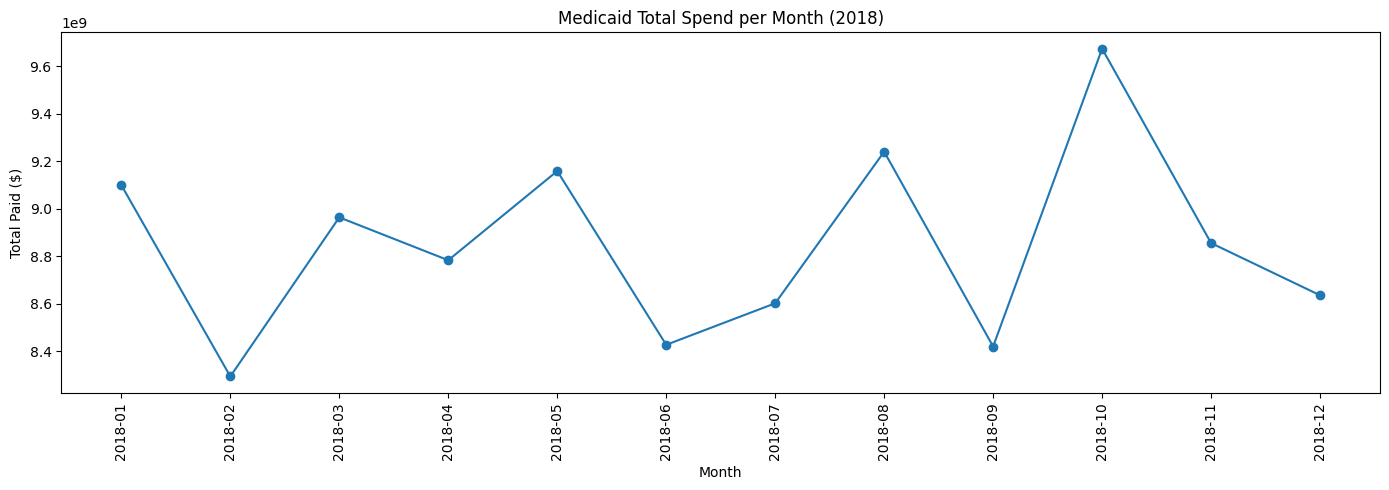

In [55]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(paid_2018["CLAIM_FROM_MONTH"], paid_2018["TOTAL_PAID"], marker="o", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Total Paid ($)")
ax.set_title("Medicaid Total Spend per Month (2018)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

A lot better graph, and although it has its ups and downs, it isn't nearly as extreme as the graph with the NPI included. 
Let's take a look at the overall year totals without the NPI to see if there are any other anomalies.

In [56]:
all_months = con.sql("""
    SELECT
        CLAIM_FROM_MONTH, SUM(TOTAL_PAID) as TOTAL_PAID    
    FROM dataset
    WHERE NOT SERVICING_PROVIDER_NPI_NUM = '5200000300'
    
    GROUP BY CLAIM_FROM_MONTH
    ORDER BY CLAIM_FROM_MONTH
""").to_df()


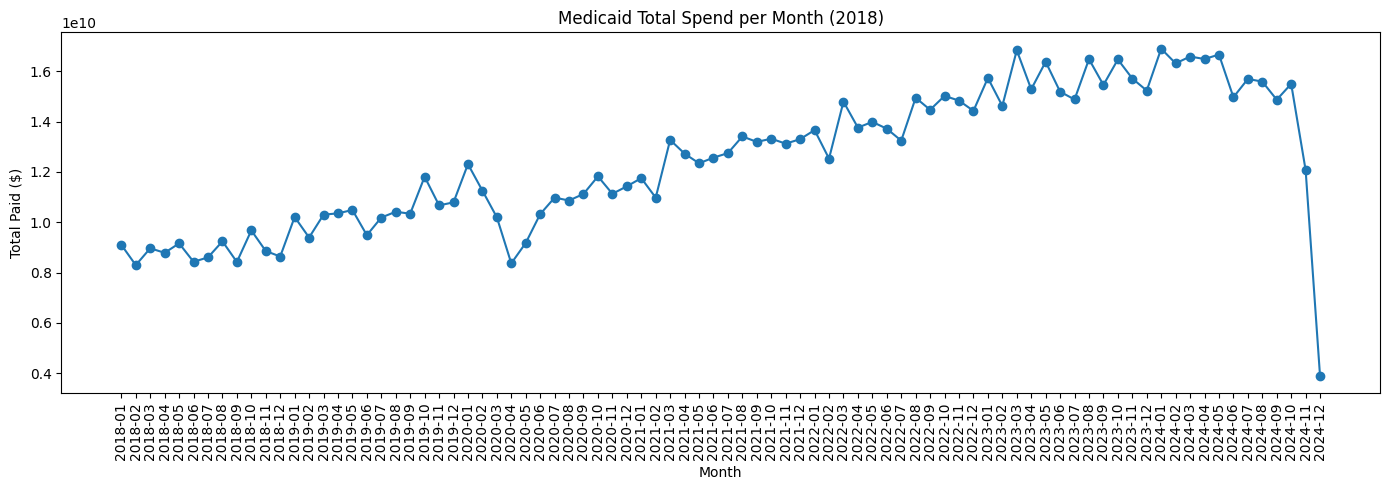

In [57]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(all_months["CLAIM_FROM_MONTH"], all_months["TOTAL_PAID"], marker="o", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Total Paid ($)")
ax.set_title("Medicaid Total Spend per Month (2018)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [58]:
all_months.sort_values(by='TOTAL_PAID', ascending=False)

,CLAIM_FROM_MONTH,TOTAL_PAID
72,2024-01,1.690373e+10
62,2023-03,1.684073e+10
76,2024-05,1.667135e+10
74,2024-03,1.659310e+10
75,2024-04,1.649349e+10
...,...,...
5,2018-06,8.426731e+09
8,2018-09,8.419541e+09
27,2020-04,8.364984e+09
1,2018-02,8.293275e+09


In [59]:
con.sql("SELECT * FROM dataset WHERE CLAIM_FROM_MONTH = '2019-10' ORDER BY TOTAL_PAID DESC")

┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────┬───────────────────┬────────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_PATIENTS │ TOTAL_CLAIM_LINES │   TOTAL_PAID   │
│         varchar          │          varchar           │  varchar   │     varchar      │     int64      │       int64       │     double     │
├──────────────────────────┼────────────────────────────┼────────────┼──────────────────┼────────────────┼───────────────────┼────────────────┤
│ NULL                     │ 5200000300                 │ 20         │ 2019-10          │           1161 │             12022 │ 14222639332.01 │
│ NULL                     │ NULL                       │ Z9525      │ 2019-10          │         597151 │           1290008 │   912402655.22 │
│ NULL                     │ NULL                       │ T1019      │ 2019-10          │         134659 │           2651539 │    189054

In [ ]:
# paid_2018 = con.sql("""
#     SELECT CLAIM_FROM_MONTH, 
#     SUM(TOTAL_PAID) as TOTAL_PAID 
#     From dataset
#     WHERE 
#     GROUP BY CLAIM_FROM_MONTH """).to_df()

ParserException: Parser Error: syntax error at or near "GROUP"

LINE 6:     GROUP BY CLAIM_FROM_MONTH 
            ^

In [62]:
con.sql("""
    SELECT 
        LENGTH(HCPCS_CODE) AS code_length,
        COUNT(*) AS count
    FROM claims_2018
    GROUP BY code_length
    ORDER BY code_length
""")


┌─────────────┬──────────┐
│ code_length │  count   │
│    int64    │  int64   │
├─────────────┼──────────┤
│           2 │        2 │
│           3 │       92 │
│           4 │    53117 │
│           5 │ 27218814 │
│           6 │       14 │
│           7 │      475 │
│           8 │        2 │
└─────────────┴──────────┘

In [63]:
con.sql("""
    SELECT         
        SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
        LENGTH(HCPCS_CODE) AS code_length,
        COUNT(*) AS count
    FROM dataset
    GROUP BY year, code_length
    ORDER BY year, code_length    
""").to_df()


,year,code_length,count
0,2018,1,3
1,2018,2,13
2,2018,3,119
3,2018,4,53164
4,2018,5,28517888
5,2018,6,82
6,2018,7,505
7,2018,8,2
8,2019,1,1
9,2019,2,371


Funny enough, 2018 is the only year where there are only 13 rows with 2 values for HCPCS code. It speaks on a broader issue of incorrect HCPCS codes in the dataset, but perhaps these 13 rows with trillions of dollars are the only rows skewing the data.